In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay,classification_report, make_scorer
)
from sklearn import set_config

In [2]:
set_config(transform_output="pandas")

# Load the data

In [3]:
df =  pd.read_csv("../../data/hyper.csv")
df.head()

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age,bmi,bp_category,bp_enconded
0,M,168,62.0,110,80,1,1,0,0,1,50,21.967120,Hypertension Stage 1,1
1,F,156,85.0,140,90,3,1,0,0,1,55,34.927679,Hypertension Stage 2,2
2,F,165,64.0,130,70,3,1,0,0,0,51,23.507805,Hypertension Stage 1,1
3,M,169,82.0,150,100,1,1,0,0,1,48,28.710479,Hypertension Stage 2,2
4,F,156,56.0,100,60,1,1,0,0,0,47,23.011177,Normal,3


In [4]:
mapping = {3:0 , 0:1 , 1:2, 2:3}

df['bp_enconded'] = df['bp_enconded'].map(mapping)

In [5]:
df.loc[:,['bp_category', 'bp_enconded' ]].head(20)

,bp_category,bp_enconded
0,Hypertension Stage 1,2
1,Hypertension Stage 2,3
2,Hypertension Stage 1,2
3,Hypertension Stage 2,3
4,Normal,0
5,Hypertension Stage 1,2
6,Hypertension Stage 1,2
7,Hypertension Stage 1,2
8,Normal,0
9,Normal,0


In [6]:
df.drop(columns=['bp_category','cholesterol','gluc','bmi','weight'], axis =1, inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68205 entries, 0 to 68204
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   gender       68205 non-null  object
 1   height       68205 non-null  int64 
 2   ap_hi        68205 non-null  int64 
 3   ap_lo        68205 non-null  int64 
 4   smoke        68205 non-null  int64 
 5   alco         68205 non-null  int64 
 6   active       68205 non-null  int64 
 7   age          68205 non-null  int64 
 8   bp_enconded  68205 non-null  int64 
dtypes: int64(8), object(1)
memory usage: 4.7+ MB


In [8]:
num_cols = ['height','ap_hi','ap_lo', 'age']

nominal_cols = ['gender','smoke','alco','active']


x = df.drop('bp_enconded', axis=1)[num_cols+nominal_cols]
y = df['bp_enconded']

X_train,X_test,Y_train,Y_test =  train_test_split(x,y , stratify=y , random_state= 42, test_size=0.2)

In [9]:
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape, sep="\n")

(54564, 8)
(54564,)
(13641, 8)
(13641,)


In [10]:
print(Y_test.value_counts(normalize=True))
print(Y_train.value_counts(normalize=True))

bp_enconded
2    0.582802
3    0.233634
0    0.138113
1    0.045451
Name: proportion, dtype: float64
bp_enconded
2    0.582802
3    0.233671
0    0.138058
1    0.045470
Name: proportion, dtype: float64


## Define categorical& num  transformer

In [11]:
num_preprocessor =  make_pipeline(
    SimpleImputer(strategy='median')
)

norminal_preprocessor = Pipeline([
    ('imputer' , SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False , drop='if_binary'))
])



preprocessor =  ColumnTransformer(
    transformers =[
        ('num_encoder', num_preprocessor,num_cols),
       ( 'nor_encoder',norminal_preprocessor, nominal_cols )

    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

### Define utility functions and tables

In [12]:
def get_errors(model, X, y):
    """Computes the error metrics for evaluating a classification model."""

    preds = model.predict(X)
    accuracy = accuracy_score(y, preds )
    recall = recall_score(y, preds , average='weighted')
    precision = precision_score(y, preds, zero_division=0.0 , average='weighted')
    return {"accuracy": accuracy, "recall": recall, "precision": precision}


def get_avg_cv_errors(cv_result):
    """Get the average value of the error metrics from the cross validation result."""

    return {
        "accuracy": cv_result["test_accuracy"].mean(),
        "recall": cv_result["test_recall"].mean(),
        "precision": cv_result["test_precision"].mean(),
    }


def plot_confusion_matrix(model, model_name, X, y, split="test"):
    """Plot the confusion matrix of a classification model."""

    ConfusionMatrixDisplay.from_estimator(model, X, y)
    plt.title(f"Confusion Matrix of {model_name} Model [{split.title()} Set]")


def log_error(model_name, errors, eval_set, perf_df):
    """Store the performance metrics of a model."""

    cols = [eval_set + "_" + err for err in ("accuracy", "recall", "precision")]
    perf_df.loc[model_name, cols] = list(errors)

In [13]:
perf_df = pd.DataFrame(
    columns=[
        "train_accuracy",
        "train_recall",
        "train_precision",
        "cv_accuracy",
        "cv_recall",
        "cv_precision",
        "test_accuracy",
        "test_recall",
        "test_precision"
    ]
)

### Build and Evaluate Baseline Model

In [14]:
base_model = DummyClassifier()  # Instantiate the model
base_model.fit(X_train, Y_train)  # Train the model

,strategy,'prior'
,random_state,None
,constant,None


In [15]:
base_train_pred = base_model.predict(X_train)  

In [16]:
base_train_pred[:20]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [17]:
# Evaluate training predictions

base_train_errors = get_errors(base_model, X_train, Y_train)
base_train_errors


{'accuracy': 0.5828018473718936,
 'recall': 0.5828018473718936,
 'precision': 0.3396579933000919}

In [18]:
# Log train error
log_error("Base Model", base_train_errors.values(), "train", perf_df)

In [19]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.582802,0.582802,0.339658,NaN,NaN,NaN,NaN,NaN,NaN


#### Get cross validation error

In [20]:
cv_results = cross_validate(base_model, X_train, Y_train, cv=5, scoring=get_errors)

In [21]:
cv_results

{'fit_time': array([0.00401616, 0.        , 0.        , 0.01797342, 0.00300837]),
 'score_time': array([0.00200891, 0.01569271, 0.        , 0.00914502, 0.        ]),
 'test_accuracy': array([0.58279117, 0.58279117, 0.58279117, 0.58279117, 0.58284457]),
 'test_recall': array([0.58279117, 0.58279117, 0.58279117, 0.58279117, 0.58284457]),
 'test_precision': array([0.33964554, 0.33964554, 0.33964554, 0.33964554, 0.3397078 ])}

In [22]:
base_avg_cv_errors = get_avg_cv_errors(cv_results)
base_avg_cv_errors

{'accuracy': np.float64(0.5828018481549488),
 'recall': np.float64(0.5828018481549488),
 'precision': np.float64(0.33965799466921515)}

In [23]:
log_error("Base Model", base_avg_cv_errors.values(), "cv", perf_df)

In [24]:
perf_df


,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.582802,0.582802,0.339658,0.582802,0.582802,0.339658,NaN,NaN,NaN


#### Evaluate model on test set

In [25]:
test_pred = base_model.predict(X_test)

In [26]:
test_pred[:10]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [27]:
base_test_errors = get_errors(base_model, X_test, Y_test)
base_test_errors

{'accuracy': 0.5828018473718936,
 'recall': 0.5828018473718936,
 'precision': 0.3396579933000919}

#### Save base model error

In [28]:
log_error("Base Model", base_test_errors.values(), "test", perf_df)

In [29]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.582802,0.582802,0.339658,0.582802,0.582802,0.339658,0.582802,0.582802,0.339658


### Plot base model confusion matrix

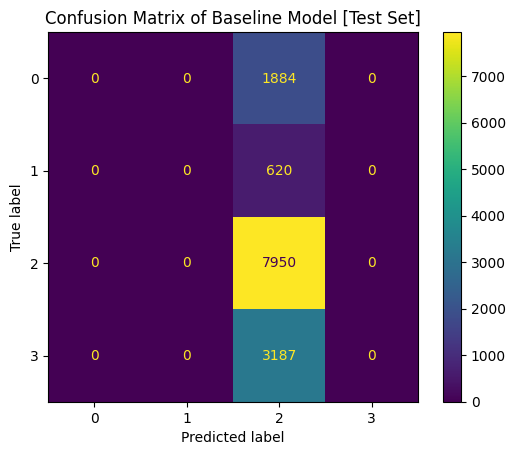

In [30]:
plot_confusion_matrix(base_model, "Baseline", X_test, Y_test)

### Build and Evaluate Logistic Regression Model

In [31]:
lg_model = LogisticRegression(max_iter=100000)

In [32]:
lg_pipeline = make_pipeline(preprocessor, lg_model)

Train the model

In [33]:
lg_pipeline.fit(X_train, Y_train)

c:\Users\dunsin\OneDrive\Desktop\Sabi data analyst\Data Science\ds_env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 13459 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,steps,"[('columntransformer', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_encoder', ...), ('nor_encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


Evaluate the model

In [34]:
train_preds = lg_pipeline.predict(X_train)
train_preds[:10]

array([2, 2, 0, 2, 2, 3, 3, 0, 0, 2])

In [35]:
lg_train_errors = get_errors(lg_pipeline, X_train, Y_train)
lg_train_errors

{'accuracy': 0.9152738069056521,
 'recall': 0.9152738069056521,
 'precision': 0.9154713526186417}

Get cross validation result

In [36]:
cv_results = cross_validate(lg_pipeline, X_train, Y_train, cv=5, scoring=get_errors)

c:\Users\dunsin\OneDrive\Desktop\Sabi data analyst\Data Science\ds_env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 13469 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\dunsin\OneDrive\Desktop\Sabi data analyst\Data Science\ds_env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 13524 iteration(s) (status=1):
STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver 

In [37]:
lg_avg_cv_errors = get_avg_cv_errors(cv_results)
lg_avg_cv_errors

{'accuracy': np.float64(0.9150722049733254),
 'recall': np.float64(0.9150722049733254),
 'precision': np.float64(0.9155164499468775)}

Evaluate the model on the test set

In [38]:
lg_test_errors = get_errors(lg_pipeline, X_test, Y_test)
lg_test_errors

{'accuracy': 0.9133494611831977,
 'recall': 0.9133494611831977,
 'precision': 0.913232837419165}

#### Log errors

In [39]:
log_error("LG Model", lg_train_errors.values(), "train", perf_df)
log_error("LG Model", lg_avg_cv_errors.values(), "cv", perf_df)
log_error("LG Model", lg_test_errors.values(), "test", perf_df)

In [40]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.582802,0.582802,0.339658,0.582802,0.582802,0.339658,0.582802,0.582802,0.339658
LG Model,0.915274,0.915274,0.915471,0.915072,0.915072,0.915516,0.913349,0.913349,0.913233


### Plot LR model confusion matrix

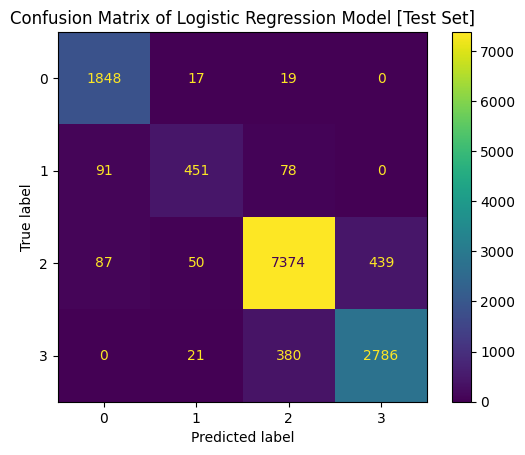

In [41]:
plot_confusion_matrix(lg_pipeline, "Logistic Regression", X_test, Y_test)

### Build and Evaluate Decision Tree Model

In [42]:
# Instantiate the model

dt_model = DecisionTreeClassifier(random_state=42)

In [43]:
# Create pipeline

dt_pipeline = make_pipeline(preprocessor, dt_model)
dt_pipeline.fit(X_train, Y_train)

,steps,"[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_encoder', ...), ('nor_encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


#### Handle the overfitting issue in the decision tree

In [44]:
dt_pipeline[-1].get_depth()

5

#### Find the optimal tree depth with grid search cv

In [45]:
precision_weighted = make_scorer(
    precision_score, average ='weighted', zero_division = 0 
)
recall_weighted = make_scorer(
    recall_score,  average = 'weighted'
)

In [46]:
scoring = {
    'accuracy': 'accuracy',
    'precision': precision_weighted,
    'recall': recall_weighted
}

In [47]:
param_grid = {"decisiontreeclassifier__max_depth": range(2, 5)}

grid_search_cv = GridSearchCV(
    dt_pipeline, param_grid=param_grid,
    scoring=scoring, refit="recall",
    return_train_score=True
)
grid_search_cv.fit(X_train, Y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'decisiontreeclassifier__max_depth': range(2, 5)}"
,scoring,"{'accuracy': 'accuracy', 'precision': make_scorer(p...ro_division=0), 'recall': make_scorer(r...rage=weighted)}"
,n_jobs,None
,refit,'recall'
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num_encoder', ...), ('nor_encoder', ...)]"


In [48]:
cv_results = pd.DataFrame(grid_search_cv.cv_results_)
cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_decisiontreeclassifier__max_depth,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,...,mean_test_recall,std_test_recall,rank_test_recall,split0_train_recall,split1_train_recall,split2_train_recall,split3_train_recall,split4_train_recall,mean_train_recall,std_train_recall
0,0.130729,0.009397,0.030282,0.005080,2,{'decisiontreeclassifier__max_depth': 2},0.914964,0.916338,0.912856,0.914597,...,0.914687,0.001110,3,0.914618,0.914275,0.915145,0.914710,0.914689,0.914687,0.000278
1,0.137265,0.021884,0.032547,0.008583,3,{'decisiontreeclassifier__max_depth': 3},0.980757,0.981032,0.981673,0.980757,...,0.981050,0.000335,2,0.981123,0.981054,0.980894,0.981123,0.981055,0.981050,0.000084
2,0.119907,0.010947,0.029831,0.006105,4,{'decisiontreeclassifier__max_depth': 4},0.991753,0.991936,0.993861,0.991386,...,0.992413,0.000930,1,0.992577,0.992532,0.992051,0.992669,0.992234,0.992413,0.000232


In [49]:
cv_cols = [
    "param_decisiontreeclassifier__max_depth",
    "mean_test_recall",
    "mean_test_accuracy",
    "mean_test_precision",
    "std_test_recall",
    "mean_train_recall",
    "std_train_recall",
    "rank_test_recall",
    "mean_test_accuracy",
    "mean_train_accuracy",
    "mean_test_precision",
    "mean_train_precision",
]

In [50]:
cv_results_subset = cv_results[cv_cols].sort_values(["rank_test_recall", "std_test_recall"])

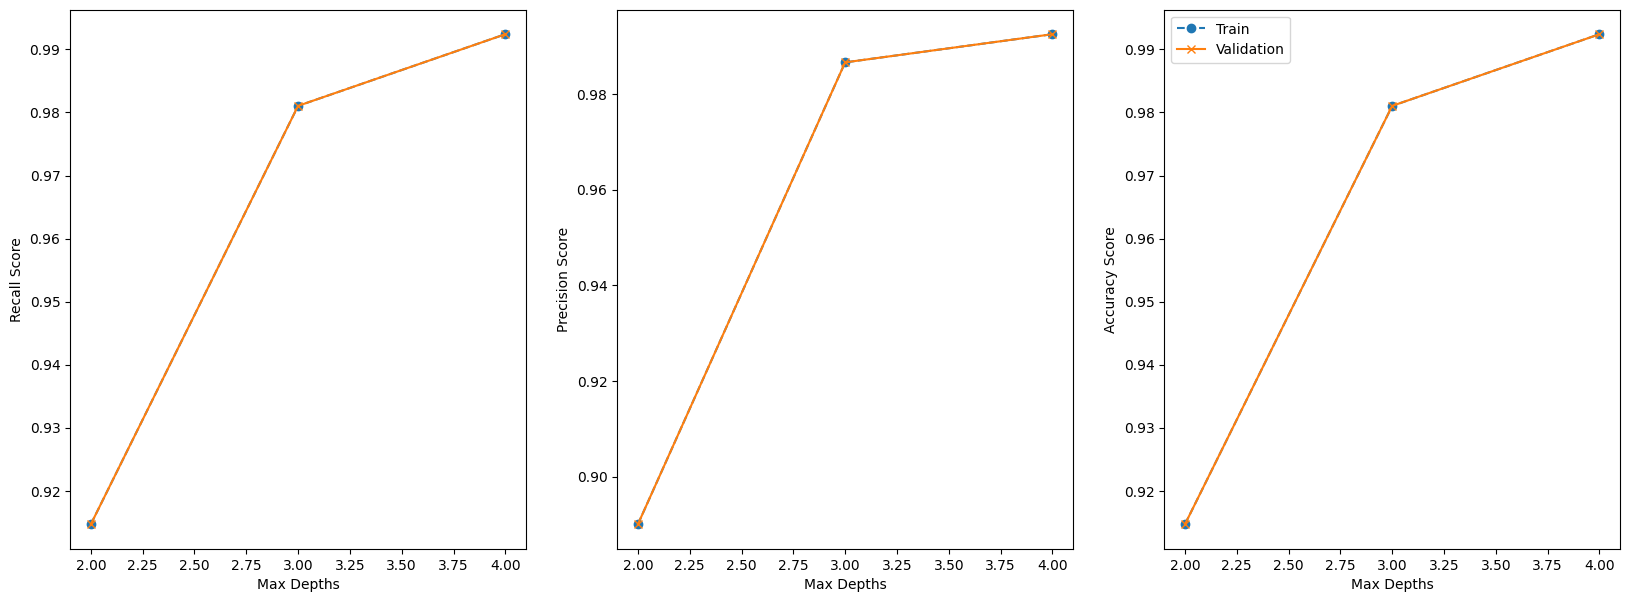

In [51]:
_, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))

ax1.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_train_recall"],linestyle="--",marker="o",  label="Train")
ax1.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_test_recall"], linestyle="-", marker="x", label="Validation")
ax1.set_xlabel("Max Depths")
ax1.set_ylabel("Recall Score")

ax2.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_train_precision"], linestyle="--",marker="o",  label="Train")
ax2.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_test_precision"], linestyle="-",marker="x", label="Validation")
ax2.set_xlabel("Max Depths")
ax2.set_ylabel("Precision Score")

ax3.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_train_accuracy"], linestyle="--",marker="o", label="Train")
ax3.plot(cv_results["param_decisiontreeclassifier__max_depth"], cv_results["mean_test_accuracy"], linestyle="-",marker="x", label="Validation")
ax3.set_xlabel("Max Depths")
ax3.set_ylabel("Accuracy Score")
plt.legend();

In [52]:
cv_results_subset.set_index("param_decisiontreeclassifier__max_depth").loc[[2, 3 ,4]]

,mean_test_recall,mean_test_accuracy,mean_test_precision,std_test_recall,mean_train_recall,std_train_recall,rank_test_recall,mean_test_accuracy,mean_train_accuracy,mean_test_precision,mean_train_precision
param_decisiontreeclassifier__max_depth,,,,,,,,,,,
2,0.914687,0.914687,0.890052,0.001110,0.914687,0.000278,3,0.914687,0.914687,0.890052,0.890050
3,0.981050,0.981050,0.986625,0.000335,0.981050,0.000084,2,0.981050,0.981050,0.986625,0.986624
4,0.992413,0.992413,0.992512,0.000930,0.992413,0.000232,1,0.992413,0.992413,0.992512,0.992510


#### Retrain the model with max_depth of 3

In [53]:
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)

In [54]:
dt_pipeline = make_pipeline(preprocessor, dt_model)
dt_pipeline.fit(X_train, Y_train)

,steps,"[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_encoder', ...), ('nor_encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


#### Evaluate the training set

In [55]:
dt_train_errors = get_errors(dt_pipeline, X_train, Y_train)
dt_train_errors

{'accuracy': 0.9810497764093542,
 'recall': 0.9810497764093542,
 'precision': 0.9866243229791202}

#### Cross validate

In [56]:
cv_results = cross_validate(dt_pipeline, X_train, Y_train, cv=5, scoring=scoring, n_jobs=-1)
dt_avg_cv_errors = get_avg_cv_errors(cv_results)
dt_avg_cv_errors

{'accuracy': np.float64(0.9810497760479915),
 'recall': np.float64(0.9810497760479915),
 'precision': np.float64(0.9866251622600908)}

#### Evaluate on test

In [57]:
dt_test_errors = get_errors(dt_pipeline, X_test, Y_test)
dt_test_errors

{'accuracy': 0.9795469540356279,
 'recall': 0.9795469540356279,
 'precision': 0.9858944510590536}

#### Log errors

In [58]:
log_error("DT Model", dt_train_errors.values(), "train", perf_df)
log_error("DT Model", dt_avg_cv_errors.values(), "cv", perf_df)
log_error("DT Model", dt_test_errors.values(), "test", perf_df)

In [59]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.582802,0.582802,0.339658,0.582802,0.582802,0.339658,0.582802,0.582802,0.339658
LG Model,0.915274,0.915274,0.915471,0.915072,0.915072,0.915516,0.913349,0.913349,0.913233
DT Model,0.98105,0.98105,0.986624,0.98105,0.98105,0.986625,0.979547,0.979547,0.985894


### Plot DT model confusion matrix

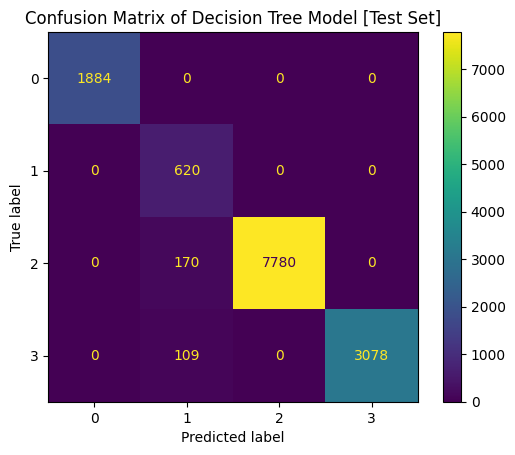

In [60]:
plot_confusion_matrix(dt_pipeline, "Decision Tree", X_test, Y_test)

## Random Forest

In [61]:
rf_model = RandomForestClassifier(max_depth=3, random_state=42)

In [62]:
rf_pipeline = make_pipeline(preprocessor, rf_model)
rf_pipeline.fit(X_train, Y_train)

,steps,"[('columntransformer', ...), ('randomforestclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_encoder', ...), ('nor_encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


#### Evaluate the training set

In [63]:
rf_train_errors = get_errors(rf_pipeline, X_train, Y_train)
rf_train_errors

{'accuracy': 0.9104171248442197,
 'recall': 0.9104171248442197,
 'precision': 0.8768828519803484}

### Evaluate on cross val set

In [64]:
rf_cv_results = cross_validate(rf_pipeline, X_train, Y_train, scoring=scoring, cv=5)
rf_avg_cv_errors = get_avg_cv_errors(rf_cv_results)
rf_avg_cv_errors

{'accuracy': np.float64(0.9143391007335275),
 'recall': np.float64(0.9143391007335275),
 'precision': np.float64(0.8798571127196533)}

#### evaluate on test set

In [65]:
rf_test_errors = get_errors(rf_pipeline, X_test, Y_test)
rf_test_errors

{'accuracy': 0.9091708819001539,
 'recall': 0.9091708819001539,
 'precision': 0.8759666244981767}

#### Log errors

In [66]:
log_error("RF Model", rf_train_errors.values(), "train", perf_df)
log_error("RF Model", rf_avg_cv_errors.values(), "cv", perf_df)
log_error("RF Model", rf_test_errors.values(), "test", perf_df)

In [67]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.582802,0.582802,0.339658,0.582802,0.582802,0.339658,0.582802,0.582802,0.339658
LG Model,0.915274,0.915274,0.915471,0.915072,0.915072,0.915516,0.913349,0.913349,0.913233
DT Model,0.98105,0.98105,0.986624,0.98105,0.98105,0.986625,0.979547,0.979547,0.985894
RF Model,0.910417,0.910417,0.876883,0.914339,0.914339,0.879857,0.909171,0.909171,0.875967


### Plot RF model confusion matrix

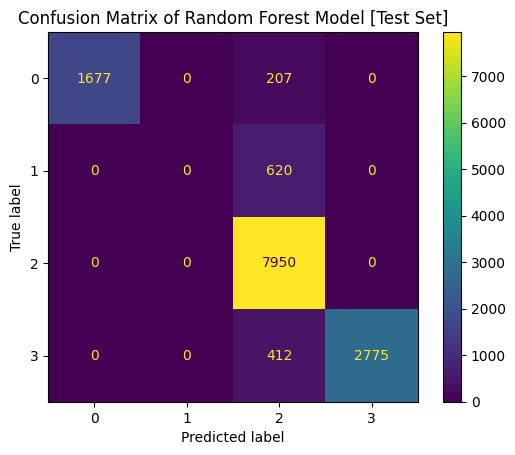

In [68]:
plot_confusion_matrix(rf_pipeline, "Random Forest", X_test, Y_test)

### Gradient Boosting

In [69]:
gb_model = GradientBoostingClassifier(max_depth=3, random_state=42)

In [70]:
gb_pipeline = make_pipeline(preprocessor, gb_model)
gb_pipeline.fit(X_train, Y_train)

,steps,"[('columntransformer', ...), ('gradientboostingclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num_encoder', ...), ('nor_encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


#### Evaluate the training set

In [71]:
gb_train_errors = get_errors(gb_pipeline, X_train, Y_train)
gb_train_errors

{'accuracy': 1.0, 'recall': 1.0, 'precision': 1.0}

#### Evaluate with cross validation

In [72]:
gb_cv_results = cross_validate(gb_pipeline, X_train, Y_train, scoring=scoring, cv=5)
gb_avg_cv_errors = get_avg_cv_errors(gb_cv_results)
gb_avg_cv_errors

{'accuracy': np.float64(1.0),
 'recall': np.float64(1.0),
 'precision': np.float64(1.0)}

#### Evaluate on test

In [73]:
gb_test_errors = get_errors(gb_pipeline, X_test, Y_test)
gb_test_errors

{'accuracy': 1.0, 'recall': 1.0, 'precision': 1.0}

#### Log errors

In [74]:
log_error("GB Model", gb_train_errors.values(), "train", perf_df)
log_error("GB Model", gb_avg_cv_errors.values(), "cv", perf_df)
log_error("GB Model", gb_test_errors.values(), "test", perf_df)

In [75]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.582802,0.582802,0.339658,0.582802,0.582802,0.339658,0.582802,0.582802,0.339658
LG Model,0.915274,0.915274,0.915471,0.915072,0.915072,0.915516,0.913349,0.913349,0.913233
DT Model,0.98105,0.98105,0.986624,0.98105,0.98105,0.986625,0.979547,0.979547,0.985894
RF Model,0.910417,0.910417,0.876883,0.914339,0.914339,0.879857,0.909171,0.909171,0.875967
GB Model,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
param_grid = {"gradientboostingclassifier__learning_rate": np.linspace(0.01, 0.1, 10)}

grid_search_cv = GridSearchCV(
    gb_pipeline,
    param_grid=param_grid,
    scoring=scoring,
    return_train_score=True,
    refit="recall",
    n_jobs=-1,
)
grid_search_cv.fit(X_train, Y_train)

In [131]:
cv_results = pd.DataFrame(grid_search_cv.cv_results_)

In [133]:
cv_cols = [
    "param_gradientboostingclassifier__learning_rate",
    "mean_test_recall",
    "mean_test_precision",
    "mean_test_accuracy",
    "mean_train_recall",
    "rank_test_recall",
    
    "mean_train_accuracy",
    
    "mean_train_precision",
]
cv_results_subset = cv_results[cv_cols].sort_values(["rank_test_recall"])

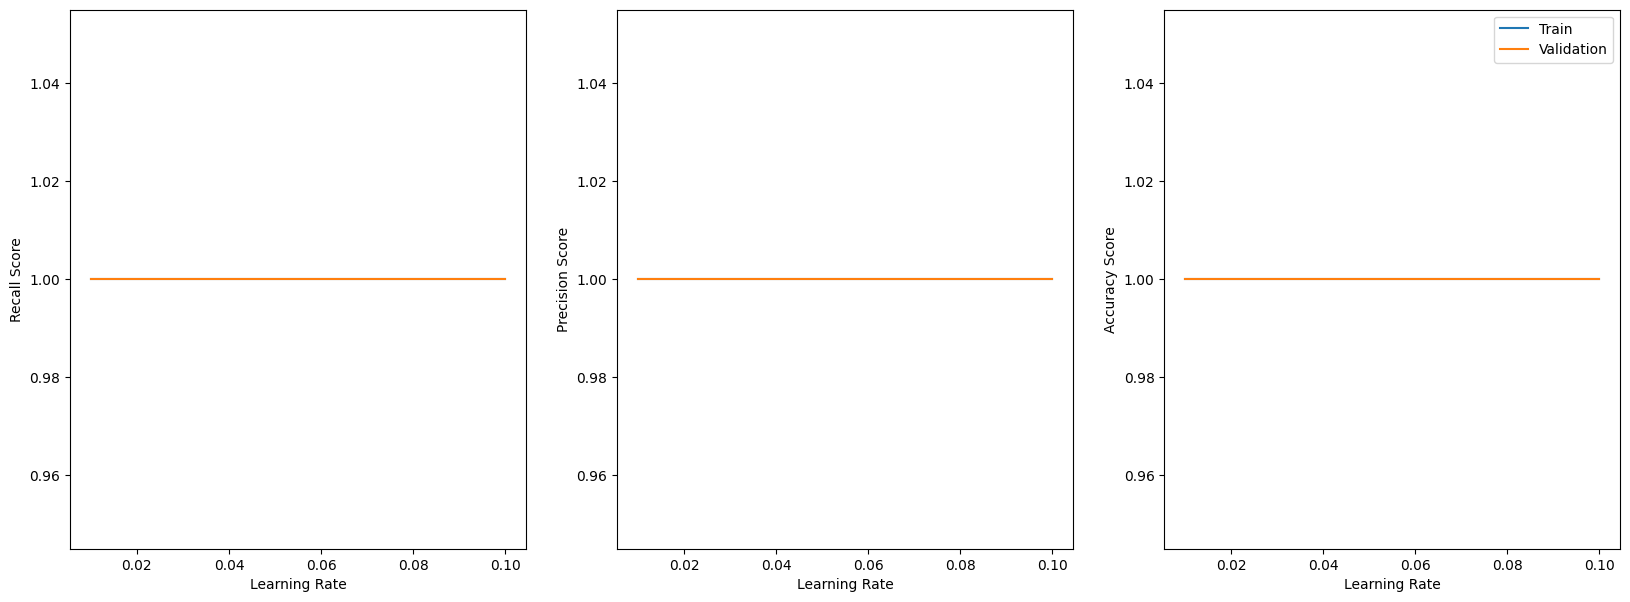

In [134]:
_, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))

ax1.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_train_recall"], label="Train")
ax1.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_test_recall"], label="Validation")
ax1.set_xlabel("Learning Rate")
ax1.set_ylabel("Recall Score")

ax2.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_train_precision"], label="Train")
ax2.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_test_precision"], label="Validation")
ax2.set_xlabel("Learning Rate")
ax2.set_ylabel("Precision Score")

ax3.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_train_accuracy"], label="Train")
ax3.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_test_accuracy"], label="Validation")
ax3.set_xlabel("Learning Rate")
ax3.set_ylabel("Accuracy Score")
plt.legend();

In [135]:
cv_results_subset.sort_values("param_gradientboostingclassifier__learning_rate")

,param_gradientboostingclassifier__learning_rate,mean_test_recall,mean_test_precision,mean_test_accuracy,mean_train_recall,rank_test_recall,mean_train_accuracy,mean_train_precision
0,0.01,1.0,1.0,1.0,1.0,1,1.0,1.0
1,0.02,1.0,1.0,1.0,1.0,1,1.0,1.0
2,0.03,1.0,1.0,1.0,1.0,1,1.0,1.0
3,0.04,1.0,1.0,1.0,1.0,1,1.0,1.0
4,0.05,1.0,1.0,1.0,1.0,1,1.0,1.0
5,0.06,1.0,1.0,1.0,1.0,1,1.0,1.0
6,0.07,1.0,1.0,1.0,1.0,1,1.0,1.0
7,0.08,1.0,1.0,1.0,1.0,1,1.0,1.0
8,0.09,1.0,1.0,1.0,1.0,1,1.0,1.0
9,0.10,1.0,1.0,1.0,1.0,1,1.0,1.0


#### Everything seems perfect, so we will go with the default 0.01 learning rate 

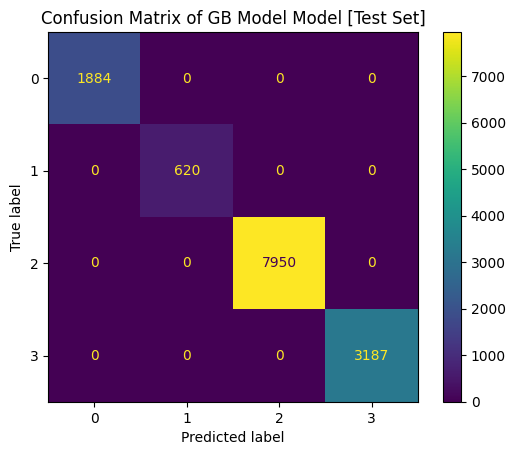

In [76]:
plot_confusion_matrix(gb_pipeline, "GB Model", X_test, Y_test)

In [77]:
gb_model.feature_importances_


array([ 6.17494538e-14,  3.71827310e-01,  6.28172690e-01, -7.88054279e-15,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00])

In [78]:
gb_model.feature_names_in_

array(['height', 'ap_hi', 'ap_lo', 'age', 'gender_M', 'smoke_1', 'alco_1',
       'active_1'], dtype=object)

### The model seems perfect already 

#### Add kmeans features to GB model

In [79]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import FeatureUnion

In [80]:
kmean_pipe = make_pipeline(
    preprocessor,
    StandardScaler(),
    KMeans(3, random_state=42)
)

In [81]:
feat_union = FeatureUnion(
    [
        ("base_feat", preprocessor),
        ("kmeans_feat", kmean_pipe),
    ],
    verbose_feature_names_out=False
)

In [82]:
gb_kmeans_pipeline = make_pipeline(
    feat_union,
    gb_model
)

In [83]:
gb_kmeans_pipeline.fit(X_train, Y_train)

,steps,"[('featureunion', ...), ('gradientboostingclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformer_list,"[('base_feat', ...), ('kmeans_feat', ...)]"
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,missing_values,nan
,strategy,'median'


#### Evaluate the training set

In [84]:
gb_km_train_errors = get_errors(gb_kmeans_pipeline, X_train, Y_train)
gb_km_train_errors

{'accuracy': 1.0, 'recall': 1.0, 'precision': 1.0}

#### Evaluate with cross validation

In [85]:
cv_results = cross_validate(gb_kmeans_pipeline, X_train, Y_train, scoring=scoring, cv=5, n_jobs=-1)
gb_avg_cv_errors = get_avg_cv_errors(cv_results)
gb_avg_cv_errors

{'accuracy': np.float64(1.0),
 'recall': np.float64(1.0),
 'precision': np.float64(1.0)}

#### Evaluate on test

In [86]:
gb_test_errors = get_errors(gb_kmeans_pipeline, X_test, Y_test)
gb_test_errors

{'accuracy': 1.0, 'recall': 1.0, 'precision': 1.0}

In [87]:
log_error("GB+KM Model", gb_train_errors.values(), "train", perf_df)
log_error("GB+KM Model", gb_avg_cv_errors.values(), "cv", perf_df)
log_error("GB+KM Model", gb_test_errors.values(), "test", perf_df)

In [88]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.582802,0.582802,0.339658,0.582802,0.582802,0.339658,0.582802,0.582802,0.339658
LG Model,0.915274,0.915274,0.915471,0.915072,0.915072,0.915516,0.913349,0.913349,0.913233
DT Model,0.98105,0.98105,0.986624,0.98105,0.98105,0.986625,0.979547,0.979547,0.985894
RF Model,0.910417,0.910417,0.876883,0.914339,0.914339,0.879857,0.909171,0.909171,0.875967
GB Model,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
GB+KM Model,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## Plot Confusion Matrix of GB_KM model

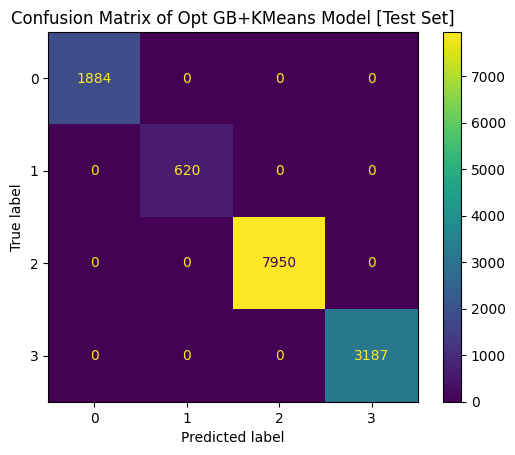

In [89]:
plot_confusion_matrix(gb_kmeans_pipeline, "Opt GB+KMeans", X_test, Y_test)

## Visualize feature importance

In [90]:
feat_imps = pd.Series(
    gb_kmeans_pipeline[-1].feature_importances_,
    index=gb_kmeans_pipeline[-1].feature_names_in_,
).sort_values()

In [91]:
def clean_feats_name(feature):
    if "__" in feature:
        return feature[feature.index("__")+2:]
    return feature

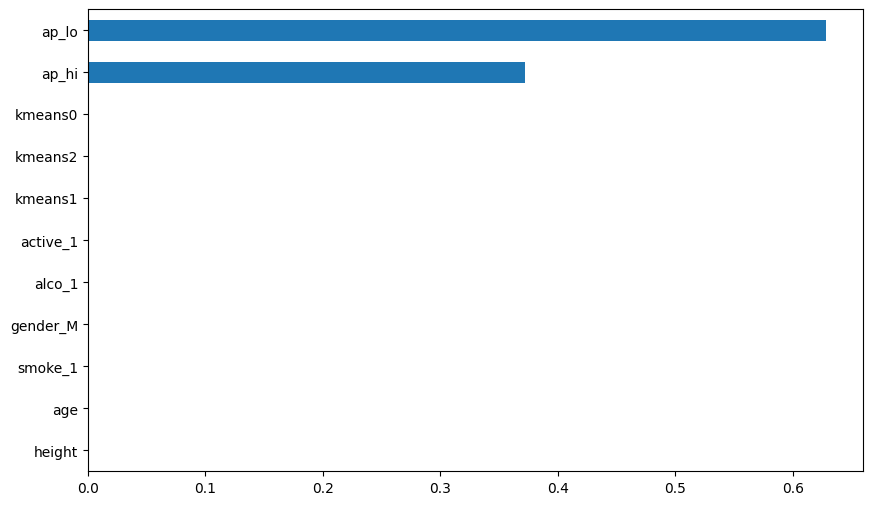

In [92]:
ax = feat_imps.plot(kind="barh", figsize=(10, 6))
ax.set_yticklabels(feat_imps.index.map(clean_feats_name));

ap_lo and ap_hi seems to be the only two  metrics detemining the outcome 

### Retrain the whole dataset 

In [93]:
gb_kmeans_pipeline.fit(x,y)

,steps,"[('featureunion', ...), ('gradientboostingclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformer_list,"[('base_feat', ...), ('kmeans_feat', ...)]"
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,missing_values,nan
,strategy,'median'


In [94]:
get_errors(gb_kmeans_pipeline,x,y)

{'accuracy': 1.0, 'recall': 1.0, 'precision': 1.0}

## Save Model

In [95]:
import joblib

In [96]:
joblib.dump(gb_kmeans_pipeline,"../../models/hyper_adv_model_v1.pkl")

['../../models/hyper_adv_model_v1.pkl']

#### Load Model

In [97]:
model = joblib.load("../../models/hyper_adv_model_v1.pkl")

In [98]:
get_errors(model,x,y)

{'accuracy': 1.0, 'recall': 1.0, 'precision': 1.0}